### Setup¶
Start importing the necessary libraries

In [89]:
import os
os.environ["PROJ_LIB"] = r"C:\Users\Lenovo\anaconda3\Library\share\proj"

import rasterio
from rasterio.mask import mask
import geopandas as gpd
from pyproj import Transformer
import numpy as np
import matplotlib.pyplot as plt


### Read City Boundaries

In [90]:
nir_folder = r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\nir_band"
red_folder = r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\red_band"

BERLIN_gdf= gpd.read_file(r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\berlin.geojson")
PARIS_gdf = gpd.read_file(r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\paris.geojson")
LONDON_gdf = gpd.read_file(r"C:\Users\Lenovo\Documents\GeoinformationDataScience\EOPF\Project\NDVI\london.json")

# Ensure CRS
for gdf in [BERLIN_gdf, PARIS_gdf, LONDON_gdf]:
    if gdf.crs is None:
        gdf.set_crs("EPSG:4326", inplace=True)

In [91]:
cities = {
    "Berlin": {
        "red": os.path.join(red_folder, "BERLIN_B04.jp2"),
        "nir": os.path.join(nir_folder, "BERLIN_B08.jp2"),
        "gdf": BERLIN_gdf,
        "utm_epsg": 32633  # UTM zone 33N
    },
    "Paris": {
        "red": os.path.join(red_folder, "PARIS_B04.jp2"),
        "nir": os.path.join(nir_folder, "PARIS_B08.jp2"),
        "gdf": PARIS_gdf,
        "utm_epsg": 32631  # UTM zone 31N
    },
    "London": {
        "red": os.path.join(red_folder, "LONDON_B04.jp2"),
        "nir": os.path.join(nir_folder, "LONDON_B08.jp2"),
        "gdf": LONDON_gdf,
        "utm_epsg": 32630  # UTM zone 30N
    }
}


### Clip Band to Raster

In [92]:
def clip_band_safe(band_path, gdf, utm_epsg):
    with rasterio.open(band_path) as src:
        raster_crs = f"EPSG:{utm_epsg}"
        transformer = Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True)
        gdf_proj = gdf.copy()
        gdf_proj["geometry"] = gdf_proj["geometry"].apply(lambda geom: transform(transformer.transform, geom))
        
        # Clip
        clipped, out_transform = mask(src, gdf_proj.geometry.values, crop=True)
        band = clipped[0].astype("float32")
        
        meta = src.meta.copy()
        meta.update({
            "height": band.shape[0],
            "width": band.shape[1],
            "transform": out_transform,
            "count": 1,
            "dtype": "float32",
            "crs": raster_crs  # assign manually
        })
    return band, meta



### Compute NDVI 

In [101]:
def compute_ndvi(red, nir):
    red = red.astype("float32")
    nir = nir.astype("float32")
    ndvi = (nir - red) / (nir + red + 1e-6)
    return ndvi


In [102]:
ndvi = compute_ndvi_array(red_clip, nir_clip)
ndvi_data[city] = {"ndvi": ndvi, "meta": meta}


### Plot NDVI

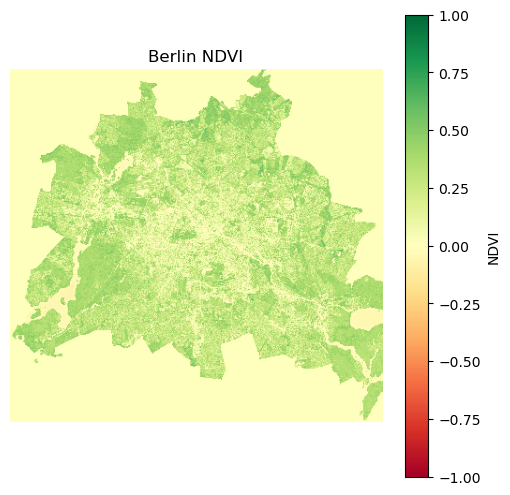

In [103]:
import matplotlib.pyplot as plt

def plot_ndvi(ndvi, title, factor=10):
    ndvi_small = ndvi[::factor, ::factor]
    plt.figure(figsize=(6, 6))
    plt.imshow(ndvi_small, cmap="RdYlGn", vmin=-1, vmax=1)
    plt.colorbar(label="NDVI")
    plt.title(title)
    plt.axis("off")
    plt.show()

for city in ndvi_data:
    plot_ndvi(ndvi_data[city]["ndvi"], f"{city} NDVI")



### Compute Mean NDVI per City

In [96]:
for city, data in ndvi_data.items():
    mean_val = np.nanmean(data["ndvi"])
    print(f"{city} mean NDVI: {mean_val:.3f}")


Berlin mean NDVI: 0.149


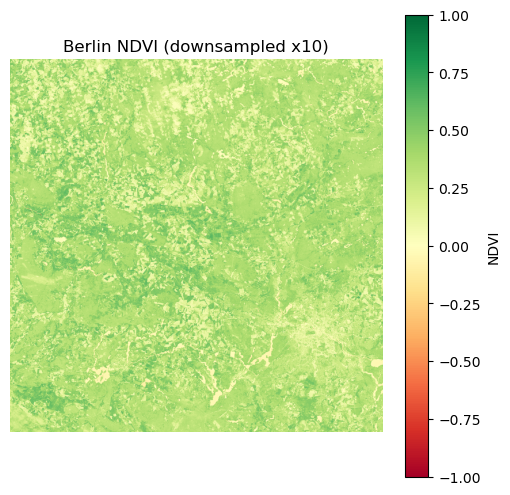

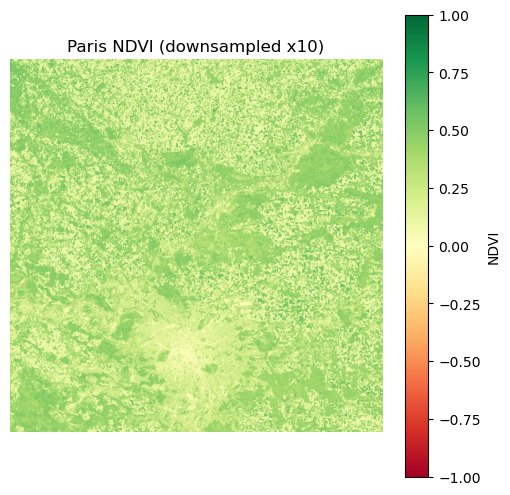

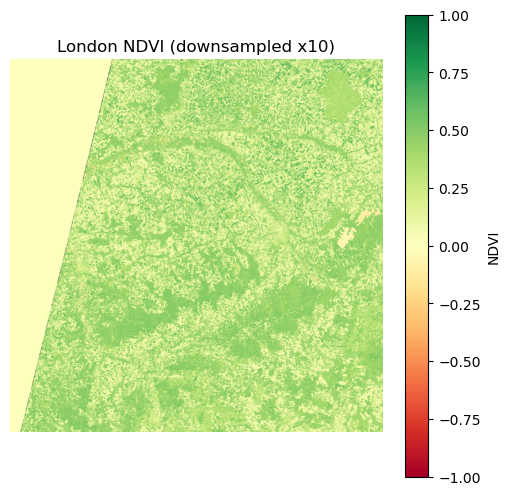

In [109]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

for city, data in cities.items():
    with rasterio.open(data["red"]) as red_src, rasterio.open(data["nir"]) as nir_src:
        # Downsample by factor of 10 (adjust as needed)
        factor = 10
        red = red_src.read(
            1,
            out_shape=(
                red_src.count,
                int(red_src.height / factor),
                int(red_src.width / factor)
            )
        ).astype("float32")
        nir = nir_src.read(
            1,
            out_shape=(
                nir_src.count,
                int(nir_src.height / factor),
                int(nir_src.width / factor)
            )
        ).astype("float32")
    
    ndvi = (nir - red) / (nir + red + 1e-6)
    
    plt.figure(figsize=(6,6))
    plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
    plt.colorbar(label="NDVI")
    plt.title(f"{city} NDVI (downsampled x{factor})")
    plt.axis("off")
    plt.show()




In [111]:
for city, data in cities.items():
    print(f"Plotting NDVI for {city}...")
    
    # Clip bands
    red_clip = clip_raster_to_city(data["red"], data["gdf"], data["utm_epsg"])
    nir_clip = clip_raster_to_city(data["nir"], data["gdf"], data["utm_epsg"])
    
    # Compute NDVI
    ndvi = compute_ndvi(red_clip, nir_clip)
    
    # Plot NDVI
    plot_ndvi(ndvi, city)


CRSError: The EPSG code is unknown. PROJ: proj_create_from_database: Cannot find proj.db